In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load all CSV files
import glob

csv_files = sorted(glob.glob('*.csv'))
raw = {}
for path in csv_files:
    name = path.replace('.csv', '')
    raw[name] = pd.read_csv(path)
    print(f'--- {path} ---')
    print(raw[name].to_string(index=False))
    print()

--- calorimeter_mass_empty.csv ---
    m  u_m
133.6  0.1
133.7  0.1
133.5  0.1
133.7  0.1
133.7  0.1

--- qal_beaker_mass_empty.csv ---
   m  u_m
56.8  0.1
56.7  0.1
56.7  0.1
56.6  0.1
56.7  0.1

--- qal_beaker_mass_with_water.csv ---
    m  u_m
248.0  0.1
247.9  0.1
247.9  0.1
247.9  0.1
247.9  0.1

--- qal_beaker_temperature_with_water.csv ---
   T  u_T
35.8  0.2

--- qal_calorimeter_temperature_with_water_after.csv ---
   T  u_T
20.0  0.2

--- qal_calorimeter_temperature_with_water_before.csv ---
   T  u_T
10.2  0.2

--- qal_calorimiter_mass_with_water_before.csv ---
    m  u_m
418.7  0.1
418.6  0.1
418.6  0.1
418.6  0.1
418.5  0.1

--- qt_calorimeter_mass_with_water_after.csv ---
 series     m  u_m
      1 716.3  0.1
      1 716.2  0.1
      1 716.3  0.1
      1 716.3  0.1
      1 716.2  0.1
      2 599.5  0.1
      2 599.5  0.1
      2 599.5  0.1
      2 599.4  0.1
      2 599.5  0.1
      3 652.0  0.1
      3 651.8  0.1
      3 651.8  0.1
      3 651.9  0.1
      3 651.8  0.1
  

In [3]:
import numpy as np

def aggregate(df):
    """Aggregate repeated measurements into a mean and combined uncertainty.

    For each measurement column <name> paired with u_<name>:
      mean  = arithmetic mean of the measurements
      u_A   = std / sqrt(N)  (type-A, standard uncertainty of the mean)
      u_B   = instrument uncertainty (type-B, taken from the u_<name> column)
      u_combined = sqrt(u_A**2 + u_B**2)

    If the dataframe has a 'series' column the aggregation is done per series
    and the result is indexed by series.  Otherwise all rows are collapsed into
    a single row.
    """
    val_cols = [c for c in df.columns if c != 'series' and not c.startswith('u_')]

    def _agg_group(g):
        row = {}
        for col in val_cols:
            u_col = 'u_' + col
            vals = g[col].dropna()
            N = len(vals)
            mean_val = vals.mean()
            u_A = vals.std(ddof=1) / np.sqrt(N) if N > 1 else 0.0
            u_B = g[u_col].mean() if u_col in g.columns else 0.0
            row[col] = mean_val
            row[u_col] = np.sqrt(u_A**2 + u_B**2)
        return pd.Series(row)

    if 'series' in df.columns:
        result = df.groupby('series')[df.columns.difference(['series'])].apply(
            lambda g: _agg_group(g)
        )
        result.index.name = 'series'
        return result
    else:
        return _agg_group(df).to_frame().T.reset_index(drop=True)

In [4]:
# Aggregate non-qt files that contain repeated measurements (multiple rows, no series column)
non_qt_multi = {
    name: df
    for name, df in raw.items()
    if not name.startswith('qt_') and 'series' not in df.columns and len(df) > 1
}

agg_single = {}
for name, df in non_qt_multi.items():
    agg_single[name] = aggregate(df)
    print(f'--- {name} (aggregated) ---')
    print(agg_single[name].to_string(index=False))
    print()

--- calorimeter_mass_empty (aggregated) ---
     m      u_m
133.64 0.107703

--- qal_beaker_mass_empty (aggregated) ---
   m      u_m
56.7 0.104881

--- qal_beaker_mass_with_water (aggregated) ---
     m     u_m
247.92 0.10198

--- qal_calorimiter_mass_with_water_before (aggregated) ---
    m      u_m
418.6 0.104881



In [5]:
# Aggregate qt_* files: group by series
qt_files = {name: df for name, df in raw.items() if name.startswith('qt_')}

agg_qt = {}
for name, df in qt_files.items():
    short = name[len('qt_'):]  # strip qt_ prefix
    agg_qt[short] = aggregate(df)
    print(f'--- {name} (aggregated by series) ---')
    print(agg_qt[short].to_string())
    print()

--- qt_calorimeter_mass_with_water_after (aggregated by series) ---
             m       u_m
series                  
1       716.26  0.102956
2       599.48  0.101980
3       651.86  0.107703
4       652.92  0.101980

--- qt_calorimeter_mass_with_water_before (aggregated by series) ---
             m       u_m
series                  
1       663.24  0.102956
2       490.88  0.101980
3       538.84  0.102956
4       652.06  0.102956

--- qt_calorimeter_temperature_with_water_after (aggregated by series) ---
           T  u_T
series           
1       12.6  0.2
2       11.2  0.2
3       16.2  0.2
4       19.0  0.2

--- qt_calorimeter_temperature_with_water_before (aggregated by series) ---
           T  u_T
series           
1       21.0  0.2
2       36.4  0.2
3       40.6  0.2
4       40.6  0.2



In [6]:
from IPython.display import display

# ── Display all data ───────────────────────────────────────────────────────────
print('=' * 62)
print('  SINGLE-MEASUREMENT DATA  (qal / calibration)')
print('=' * 62)

for key in [
    'qal_beaker_temperature_with_water',
    'qal_calorimeter_temperature_with_water_before',
    'qal_calorimeter_temperature_with_water_after',
]:
    if key in raw and len(raw[key]) >= 1:
        print(f'\n  {key}')
        display(raw[key])

print('\n  (aggregated from repeated measurements)')
for key, df in agg_single.items():
    print(f'\n  {key}')
    display(df)

print('\n' + '=' * 62)
print('  PER-SERIES DATA  (qt experiments, aggregated by series)')
print('=' * 62)
for key, df in agg_qt.items():
    print(f'\n  {key}')
    display(df)

# ── Extract scalar variables ───────────────────────────────────────────────────

# single-row raw temperature files
T_beaker           = raw['qal_beaker_temperature_with_water']['T'].iloc[0]
u_T_beaker         = raw['qal_beaker_temperature_with_water']['u_T'].iloc[0]

T_cal_qal_before   = raw['qal_calorimeter_temperature_with_water_before']['T'].iloc[0]
u_T_cal_qal_before = raw['qal_calorimeter_temperature_with_water_before']['u_T'].iloc[0]

T_cal_qal_after    = raw['qal_calorimeter_temperature_with_water_after']['T'].iloc[0]
u_T_cal_qal_after  = raw['qal_calorimeter_temperature_with_water_after']['u_T'].iloc[0]

# aggregated non-qt repeated measurements
m_cal_empty        = agg_single['calorimeter_mass_empty']['m'].iloc[0]
u_m_cal_empty      = agg_single['calorimeter_mass_empty']['u_m'].iloc[0]

m_beaker_empty     = agg_single['qal_beaker_mass_empty']['m'].iloc[0]
u_m_beaker_empty   = agg_single['qal_beaker_mass_empty']['u_m'].iloc[0]

m_beaker_water     = agg_single['qal_beaker_mass_with_water']['m'].iloc[0]
u_m_beaker_water   = agg_single['qal_beaker_mass_with_water']['u_m'].iloc[0]

# per-series qt data — pandas Series indexed by series number (1, 2, 3, 4)
m_cal_after        = agg_qt['calorimeter_mass_with_water_after']['m']
u_m_cal_after      = agg_qt['calorimeter_mass_with_water_after']['u_m']

m_cal_before       = agg_qt['calorimeter_mass_with_water_before']['m']
u_m_cal_before     = agg_qt['calorimeter_mass_with_water_before']['u_m']

T_cal_after        = agg_qt['calorimeter_temperature_with_water_after']['T']
u_T_cal_after      = agg_qt['calorimeter_temperature_with_water_after']['u_T']

T_cal_before       = agg_qt['calorimeter_temperature_with_water_before']['T']
u_T_cal_before     = agg_qt['calorimeter_temperature_with_water_before']['u_T']

# ── Variable reference ─────────────────────────────────────────────────────────
print('\n' + '=' * 62)
print('  VARIABLE REFERENCE')
print('=' * 62)
print("""
Scalars — use directly in formulas:
  m_cal_empty,        u_m_cal_empty        calorimeter mass, empty           [g]
  m_beaker_empty,     u_m_beaker_empty     beaker mass, empty                [g]
  m_beaker_water,     u_m_beaker_water     beaker + water mass (qal)         [g]
  T_beaker,           u_T_beaker           beaker water temperature (qal)   [°C]
  T_cal_qal_before,   u_T_cal_qal_before   calorimeter temp before (qal)    [°C]
  T_cal_qal_after,    u_T_cal_qal_after    calorimeter temp after  (qal)    [°C]

Per-series — index with [s] where s ∈ {1, 2, 3, 4}:
  m_cal_before[s],    u_m_cal_before[s]    calorimeter + water mass before   [g]
  m_cal_after[s],     u_m_cal_after[s]     calorimeter + water mass after    [g]
  T_cal_before[s],    u_T_cal_before[s]    calorimeter water temp before    [°C]
  T_cal_after[s],     u_T_cal_after[s]     calorimeter water temp after     [°C]
""")

  SINGLE-MEASUREMENT DATA  (qal / calibration)

  qal_beaker_temperature_with_water


,T,u_T
0,35.8,0.2



  qal_calorimeter_temperature_with_water_before


,T,u_T
0,10.2,0.2



  qal_calorimeter_temperature_with_water_after


...


  calorimeter_temperature_with_water_after


,T,u_T
series,,
1,12.6,0.2
2,11.2,0.2
3,16.2,0.2
4,19.0,0.2



  calorimeter_temperature_with_water_before


,T,u_T
series,,
1,21.0,0.2
2,36.4,0.2
3,40.6,0.2
4,40.6,0.2



  VARIABLE REFERENCE

Scalars — use directly in formulas:
  m_cal_empty,        u_m_cal_empty        calorimeter mass, empty           [g]
  m_beaker_empty,     u_m_beaker_empty     beaker mass, empty                [g]
  m_beaker_water,     u_m_beaker_water     beaker + water mass (qal)         [g]
  T_beaker,           u_T_beaker           beaker water temperature (qal)   [°C]
  T_cal_qal_before,   u_T_cal_qal_before   calorimeter temp before (qal)    [°C]
  T_cal_qal_after,    u_T_cal_qal_after    calorimeter temp after  (qal)    [°C]

Per-series — index with [s] where s ∈ {1, 2, 3, 4}:
  m_cal_before[s],    u_m_cal_before[s]    calorimeter + water mass before   [g]
  m_cal_after[s],     u_m_cal_after[s]     calorimeter + water mass after    [g]
  T_cal_before[s],    u_T_cal_before[s]    calorimeter water temp before    [°C]
  T_cal_after[s],     u_T_cal_after[s]     calorimeter water temp after     [°C]



In [7]:
# ── Stałe fizyczne ────────────────────────────────────────────────────────────
C_AL = 900   # J/(kg·K) — tablicowe ciepło właściwe aluminium
C_W  = 4187  # J/(kg·K) — tablicowe ciepło właściwe wody

print(f'C_AL = {C_AL} J/(kg·K)')
print(f'C_W  = {C_W}  J/(kg·K)')

C_AL = 900 J/(kg·K)
C_W  = 4187  J/(kg·K)


In [8]:
# ── Ciepło właściwe kalorymetru (aluminium) — wzór (2.4) ─────────────────────
#
# c_k = [ m_g·C_W·(T_g − T_k) − m_z·C_W·(T_k − T_z) ] / [ m_k·(T_k − T_z) ]

# ── Masa gorącej wody (ze zlewki) ─────────────────────────────────────────────
m_g_g   = m_beaker_water - m_beaker_empty
u_m_g_g = np.sqrt(u_m_beaker_water**2 + u_m_beaker_empty**2)
m_g  = m_g_g  / 1000
u_m_g = u_m_g_g / 1000

# ── Masa zimnej wody w kalorymetrze ───────────────────────────────────────────
df_qal_cal_before = raw['qal_calorimiter_mass_with_water_before']
if df_qal_cal_before.empty:
    print('BRAK DANYCH: qal_calorimiter_mass_with_water_before.csv jest pusty.')
    m_z = float('nan');  u_m_z = float('nan')
else:
    agg_qcb = aggregate(df_qal_cal_before)
    m_cal_qal_before_g   = agg_qcb['m'].iloc[0]
    u_m_cal_qal_before_g = agg_qcb['u_m'].iloc[0]
    m_z_g   = m_cal_qal_before_g - m_cal_empty
    u_m_z_g = np.sqrt(u_m_cal_qal_before_g**2 + u_m_cal_empty**2)
    m_z  = m_z_g  / 1000;  u_m_z = u_m_z_g / 1000

# ── Masa kalorymetru ──────────────────────────────────────────────────────────
m_k   = m_cal_empty / 1000;  u_m_k = u_m_cal_empty / 1000

# ── Temperatury [°C] ──────────────────────────────────────────────────────────
T_g   = T_beaker;          u_T_g   = u_T_beaker
T_z   = T_cal_qal_before;  u_T_z   = u_T_cal_qal_before
T_k_q = T_cal_qal_after;   u_T_k_q = u_T_cal_qal_after

# ── Podsumowanie mas pochodnych ───────────────────────────────────────────────
print('─' * 50)
print('  Masy pochodne — wyznaczanie c_k')
print('─' * 50)
print(f'  {"Wielkość":<22}  {"wartość [g]":>10}  {"u [g]":>8}')
print(f'  {"m_g  (gorąca woda)":<22}  {m_g_g:>10.2f}  {u_m_g_g:>8.3f}')
print(f'  {"m_z  (zimna woda)":<22}  {m_z_g:>10.2f}  {u_m_z_g:>8.3f}')
print(f'  {"m_k  (kalorymetr)":<22}  {m_k*1000:>10.2f}  {u_m_k*1000:>8.3f}')
print()

# ── Wartość c_k ───────────────────────────────────────────────────────────────
num_ck = m_g * C_W * (T_g - T_k_q) - m_z * C_W * (T_k_q - T_z)
den_ck = m_k * (T_k_q - T_z)
c_k = num_ck / den_ck

# ── Pochodne cząstkowe ────────────────────────────────────────────────────────
dck_dmg  =  C_W * (T_g - T_k_q) / den_ck
dck_dmz  = -C_W / m_k
dck_dmk  = -c_k / m_k
dck_dTg  =  m_g * C_W / den_ck
dck_dTz  = (m_z * C_W * den_ck + num_ck * m_k) / den_ck**2
dck_dTkq = (-(m_g + m_z) * C_W * den_ck - num_ck * m_k) / den_ck**2

contrib_ck = {
    'u(m_g)': abs(dck_dmg)  * u_m_g,
    'u(m_z)': abs(dck_dmz)  * u_m_z,
    'u(m_k)': abs(dck_dmk)  * u_m_k,
    'u(T_g)': abs(dck_dTg)  * u_T_g,
    'u(T_z)': abs(dck_dTz)  * u_T_z,
    'u(T_k)': abs(dck_dTkq) * u_T_k_q,
}
u_ck = np.sqrt(sum(v**2 for v in contrib_ck.values()))

print('─' * 50)
print('  Ciepło właściwe kalorymetru (aluminium)')
print('─' * 50)
print(f'  T_g = {T_g:.1f} ± {u_T_g:.1f} °C')
print(f'  T_z = {T_z:.1f} ± {u_T_z:.1f} °C')
print(f'  T_k = {T_k_q:.1f} ± {u_T_k_q:.1f} °C')
print()
print(f'  c_k = {c_k:.1f} ± {u_ck:.1f} J/(kg·K)')
print(f'  (tablicowo dla Al: {C_AL} J/(kg·K))')
print()
print('  Składowe niepewności u(c_k):')
for name, val in contrib_ck.items():
    pct = val**2 / u_ck**2 * 100
    print(f'    {name:<10} {val:>8.2f} J/(kg·K)   ({pct:5.1f}% wariancji)')

──────────────────────────────────────────────────
  Masy pochodne — wyznaczanie c_k
──────────────────────────────────────────────────
  Wielkość                wartość [g]     u [g]
  m_g  (gorąca woda)          191.22     0.146
  m_z  (zimna woda)           284.96     0.150
  m_k  (kalorymetr)           133.64     0.108

──────────────────────────────────────────────────
  Ciepło właściwe kalorymetru (aluminium)
──────────────────────────────────────────────────
  T_g = 35.8 ± 0.2 °C
  T_z = 10.2 ± 0.2 °C
  T_k = 20.0 ± 0.2 °C

  c_k = 731.0 ± 394.8 J/(kg·K)
  (tablicowo dla Al: 900 J/(kg·K))

  Składowe niepewności u(c_k):
    u(m_g)         7.39 J/(kg·K)   (  0.0% wariancji)
    u(m_z)         4.71 J/(kg·K)   (  0.0% wariancji)
    u(m_k)         0.59 J/(kg·K)   (  0.0% wariancji)
    u(T_g)       122.27 J/(kg·K)   (  9.6% wariancji)
    u(T_z)       197.12 J/(kg·K)   ( 24.9% wariancji)
    u(T_k)       319.39 J/(kg·K)   ( 65.4% wariancji)


In [9]:
# ── Ciepło topnienia lodu — wzór (2.2), dla każdej serii ─────────────────────
#
# q_t = [ (C_W·m_w + C_AL·m_k)·(T_p − T_k) ] / m_l  −  C_W·T_k

series_ids = m_cal_before.index.tolist()
qt_vals  = []
qt_uncs  = []
mw_vals  = []   # masa wody w kalorymetrze przed lodem [g]
mw_uncs  = []
ml_vals  = []   # masa dosypanego lodu [g]
ml_uncs  = []

for s in series_ids:
    m_cal_bef_g = m_cal_before[s];   u_cal_bef_g = u_m_cal_before[s]
    m_cal_aft_g = m_cal_after[s];    u_cal_aft_g = u_m_cal_after[s]
    m_cal_emp_g = m_cal_empty;       u_cal_emp_g = u_m_cal_empty

    # ── Masy pochodne [g] ─────────────────────────────────────────────────────
    m_w_g  = m_cal_bef_g - m_cal_emp_g
    u_mw_g = np.sqrt(u_cal_bef_g**2 + u_cal_emp_g**2)
    m_l_g  = m_cal_aft_g - m_cal_bef_g
    u_ml_g = np.sqrt(u_cal_aft_g**2 + u_cal_bef_g**2)

    mw_vals.append(m_w_g);  mw_uncs.append(u_mw_g)
    ml_vals.append(m_l_g);  ml_uncs.append(u_ml_g)

    # ── Przeliczenie na kg ─────────────────────────────────────────────────────
    m_w   = m_w_g  / 1000
    m_l   = m_l_g  / 1000
    m_k_s = m_cal_emp_g / 1000

    # ── Temperatury ───────────────────────────────────────────────────────────
    T_p = T_cal_before[s];  u_Tp = u_T_cal_before[s]
    T_k = T_cal_after[s];   u_Tk = u_T_cal_after[s]

    # ── Wartość q_t ───────────────────────────────────────────────────────────
    cap = C_W * m_w + C_AL * m_k_s
    dT  = T_p - T_k
    qt  = cap * dT / m_l - C_W * T_k

    # ── Pochodne cząstkowe ────────────────────────────────────────────────────
    dqt_dmw = C_W  * dT / m_l
    dqt_dmk = C_AL * dT / m_l
    dqt_dml = -cap * dT / m_l**2
    dqt_dTp =  cap / m_l
    dqt_dTk = -cap / m_l - C_W

    # ── Chain rule do surowych pomiarów ───────────────────────────────────────
    dqt_d_mbef = (dqt_dmw *  1 + dqt_dml * -1) / 1000
    dqt_d_maft =  dqt_dml / 1000
    dqt_d_memp = (dqt_dmw * -1 + dqt_dmk *  1) / 1000

    contrib = {
        'u(m_cal_before)': abs(dqt_d_mbef) * u_cal_bef_g,
        'u(m_cal_after) ': abs(dqt_d_maft) * u_cal_aft_g,
        'u(m_cal_empty) ': abs(dqt_d_memp) * u_cal_emp_g,
        'u(T_before)    ': abs(dqt_dTp)    * u_Tp,
        'u(T_after)     ': abs(dqt_dTk)    * u_Tk,
    }
    u_qt = np.sqrt(sum(v**2 for v in contrib.values()))

    qt_vals.append(qt)
    qt_uncs.append(u_qt)

    print(f'════ Seria {s} ════')
    print(f'  m_w = {m_w_g:.2f} ± {u_mw_g:.3f} g   '
          f'  m_l = {m_l_g:.2f} ± {u_ml_g:.3f} g   '
          f'  T_p = {T_p:.1f} ± {u_Tp:.1f} °C   '
          f'  T_k = {T_k:.1f} ± {u_Tk:.1f} °C')
    print(f'  q_t = {qt:.0f} ± {u_qt:.0f} J/kg')
    print('  Składowe niepewności:')
    for name, val in contrib.items():
        pct = val**2 / u_qt**2 * 100
        print(f'    {name}  {val:>8.0f} J/kg   ({pct:5.1f}% wariancji)')
    print()

qt_vals = np.array(qt_vals)
qt_uncs = np.array(qt_uncs)

# ── Podsumowanie mas pochodnych per seria ─────────────────────────────────────
print('─' * 55)
print('  Masy pochodne per seria')
print('─' * 55)
print(f'  {"Seria":>5}  {"m_w [g]":>10}  {"u_mw [g]":>9}  {"m_l [g]":>10}  {"u_ml [g]":>9}')
print('  ' + '─' * 51)
for s, mw, umw, ml, uml in zip(series_ids, mw_vals, mw_uncs, ml_vals, ml_uncs):
    print(f'  {s:>5}  {mw:>10.2f}  {umw:>9.3f}  {ml:>10.2f}  {uml:>9.3f}')

════ Seria 1 ════
  m_w = 529.60 ± 0.149 g     m_l = 53.02 ± 0.146 g     T_p = 21.0 ± 0.2 °C     T_k = 12.6 ± 0.2 °C
  q_t = 317609 ± 13120 J/kg
  Składowe niepewności:
    u(m_cal_before)       787 J/kg   (  0.4% wariancji)
    u(m_cal_after)        719 J/kg   (  0.3% wariancji)
    u(m_cal_empty)         56 J/kg   (  0.0% wariancji)
    u(T_before)          8818 J/kg   ( 45.2% wariancji)
    u(T_after)           9656 J/kg   ( 54.2% wariancji)

════ Seria 2 ════
  m_w = 357.24 ± 0.148 g     m_l = 108.60 ± 0.144 g     T_p = 36.4 ± 0.2 °C     T_k = 11.2 ± 0.2 °C
  q_t = 328098 ± 4872 J/kg
  Składowe niepewności:
    u(m_cal_before)       451 J/kg   (  0.9% wariancji)
    u(m_cal_after)        352 J/kg   (  0.5% wariancji)
    u(m_cal_empty)         82 J/kg   (  0.0% wariancji)
    u(T_before)          2976 J/kg   ( 37.3% wariancji)
    u(T_after)           3814 J/kg   ( 61.3% wariancji)

════ Seria 3 ════
  m_w = 405.20 ± 0.149 g     m_l = 113.02 ± 0.149 g     T_p = 40.6 ± 0.2 °C     T_

In [10]:
# ── Ważona średnia q_t — z wykluczeniem serii 4 ───────────────────────────────
#
# Seria 4: m_l ≈ 0.86 g — do kalorymetru trafiła śladowa ilość lodu.
# Wynik q_t ≈ 57 MJ/kg (170× wartość tablicowa) jest niefizyczny
# i wynika z numerycznej niestabilności dzielenia przez ~0.
# Seria 4 jest odrzucana z dalszych obliczeń.

QT_LITERATURE = 334_000  # J/kg   (tablicowa wartość ciepła topnienia lodu)

print('  Powód odrzucenia serii 4:')
print(f'    m_l[4] = {ml_vals[3]:.2f} ± {ml_uncs[3]:.3f} g  →  q_t[4] ≈ {qt_vals[3]/1000:.0f} kJ/kg')
print()

# ── Tylko serie 1–3 ───────────────────────────────────────────────────────────
valid    = np.array(series_ids) != 4
qt_valid = qt_vals[valid]
u_valid  = qt_uncs[valid]
ids_valid = np.array(series_ids)[valid]

weights   = 1.0 / u_valid**2
qt_mean   = np.sum(weights * qt_valid) / np.sum(weights)
u_qt_mean = 1.0 / np.sqrt(np.sum(weights))

print('─' * 55)
print('  Wyniki q_t  (serie 1–3)')
print('─' * 55)
print(f'  {"Seria":>5}  {"q_t [J/kg]":>12}  {"u [J/kg]":>10}  {"waga":>8}')
print('  ' + '─' * 45)
for s, qt, u, w in zip(ids_valid, qt_valid, u_valid, weights):
    print(f'  {s:>5}  {qt:>12.0f}  {u:>10.0f}  {w/weights.sum()*100:>7.1f}%')
print()
print('─' * 55)
print('  Ważona średnia ciepła topnienia lodu')
print('─' * 55)
print(f'  q_t = {qt_mean:.0f} ± {u_qt_mean:.0f} J/kg')
print(f'       = ({qt_mean/1000:.1f} ± {u_qt_mean/1000:.1f}) kJ/kg')
print()
print(f'  Wartość tablicowa: {QT_LITERATURE/1000:.0f} kJ/kg')
rel_err = abs(qt_mean - QT_LITERATURE) / QT_LITERATURE * 100
print(f'  Odchylenie względne: {rel_err:.1f}%')

  Powód odrzucenia serii 4:
    m_l[4] = 0.86 ± 0.145 g  →  q_t[4] ≈ 57459 kJ/kg

───────────────────────────────────────────────────────
  Wyniki q_t  (serie 1–3)
───────────────────────────────────────────────────────
  Seria    q_t [J/kg]    u [J/kg]      waga
  ─────────────────────────────────────────────
      1        317609       13120      6.8%
      2        328098        4872     49.7%
      3        324412        5207     43.5%

───────────────────────────────────────────────────────
  Ważona średnia ciepła topnienia lodu
───────────────────────────────────────────────────────
  q_t = 325777 ± 3433 J/kg
       = (325.8 ± 3.4) kJ/kg

  Wartość tablicowa: 334 kJ/kg
  Odchylenie względne: 2.5%


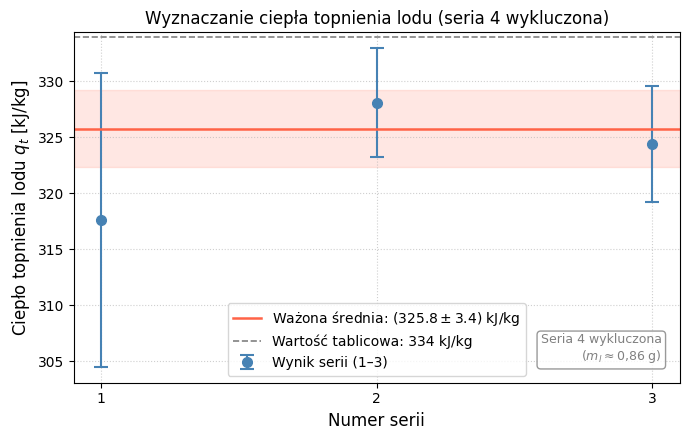

Wykres zapisany jako qt_results.pdf


In [11]:
# ── Wykres q_t dla serii 1–3 + ważona średnia ────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.array(ids_valid, dtype=float)

ax.errorbar(x, qt_valid / 1000, yerr=u_valid / 1000,
            fmt='o', color='steelblue', capsize=5, capthick=1.5,
            markersize=7, linewidth=1.5, label='Wynik serii (1–3)')

ax.axhline(qt_mean / 1000, color='tomato', linewidth=1.8,
           label=f'Ważona średnia: $({qt_mean/1000:.1f} \\pm {u_qt_mean/1000:.1f})$ kJ/kg')
ax.axhspan((qt_mean - u_qt_mean) / 1000, (qt_mean + u_qt_mean) / 1000,
           color='tomato', alpha=0.15)
ax.axhline(QT_LITERATURE / 1000, color='gray', linewidth=1.2, linestyle='--',
           label=f'Wartość tablicowa: {QT_LITERATURE/1000:.0f} kJ/kg')

ax.set_xlabel('Numer serii', fontsize=12)
ax.set_ylabel(r'Ciepło topnienia lodu $q_t$ [kJ/kg]', fontsize=12)
ax.set_title('Wyznaczanie ciepła topnienia lodu (seria 4 wykluczona)', fontsize=12)
ax.set_xticks(ids_valid)
ax.legend(fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

# Adnotacja o wykluczonej serii 4
ax.annotate('Seria 4 wykluczona\n($m_l \\approx 0{,}86$ g)',
            xy=(0.97, 0.05), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=9, color='gray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

fig.tight_layout()
fig.savefig('qt_results.pdf')
plt.show()
print('Wykres zapisany jako qt_results.pdf')